# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Two trials are registered. **Best = trial_01** (objective 0.1127 +/- 0.0825, config `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968`, 0 diverged cells).

- **trial_01 (0.1127):** mu rel-RMSE 77.1% (bias -4.1), gamma rel-RMSE 21.5% (bias -1.4). gamma accurate at high T (T100 within ~0.7%) and degrading only at low T (T05 -45/-29%). mu overshoots strongly at mid transmission (1nW T20 +157%, 3nW T05 +137%) and undershoots at high transmission (3nW T60 -23%, T100 -38%).
- **trial_02 (0.1449):** config `lr_mu=0.2833`, `mu_anneal=0.1501`, `lr_gamma=0.6746`, `gamma_anneal=0.2475`. Compared with trial_01 this was *more sustained mu travel* (higher lr_mu, much less mu-LR decay). Result: objective worsened (0.1127 -> 0.1449), mu rel-RMSE 77% -> 136% (the mid/low-T overshoot grew to +257% / +275%) and gamma rel-RMSE 21% -> 47%, plus **1 diverged cell** (1nW T05, gamma -2.20) that trial_01 did not have. 3nW T100 undershoot barely changed (-38% -> -29%).

So the campaign's only directional signal so far is that **increasing sustained mu travel is harmful**; the smaller-travel schedule of trial_01 is the current best. Cell 2 still reports `phase = uniform` (2/5 trials): no expected-improvement values yet, so the choice remains exploratory. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

Schedule convention: `lr_mu(t) = lr_mu*(1 - mu_anneal*t/n_iter)`, likewise for gamma; effective mu travel scales like `lr_mu*(1 - mu_anneal/2)*n_iter`.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.07708425042926192, "lr_gamma": 0.2749699812662947, "lr_mu": 0.40163086027716643, "mu_anneal": 0.5821620360643678}
 2 |      - | {"gamma_anneal": 0.08471577801635927, "lr_gamma": 0.46147059322465006, "lr_mu": 0.24213039257971283, "mu_anneal": 0.15973891463707857}
 3 |      - | {"gamma_anneal": 0.6611194362682931, "lr_gamma": 0.15798841892533322, "lr_mu": 0.1986579542953527, "mu_anneal": 0.5167401826213637}
 4 |      - | {"gamma_anneal": 0.38756521837276003, "lr_gamma": 0.6074586428662337, "lr_mu": 0.3702297047096193, "mu_anneal": 0.9562672548360985}
 5 |      - | {"gamma_anneal": 0.25578104737391233, "lr_gamma": 0.6661198467258338, "lr_mu": 0.34962691835172693, "mu_anneal": 0.2927207490124871}
 6 |      - | {"gamma_anneal": 0.0013410751579525538, "lr_gamma": 0.9747872610280921, "lr_mu": 0.15270860539335346, "mu_anneal": 0.3139860020343368}
 7 |      - | {"gamma_anneal": 0.8025399634006415, "lr_gamma": 0.

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Two trials, both comparable, and they disagree in a useful way: trial_01 (smaller, more-decayed mu travel) is best at 0.1127, trial_02 (larger, less-decayed mu travel) is worse at 0.1449 and added a low-T gamma divergence. There are still no expected-improvement values (cell 2 `phase = uniform`, 2/5), so the choice follows the one clear signal: **mu travel larger than trial_01's hurts**. The informative next move is therefore to probe the opposite side of that axis — an even smaller mu travel — while keeping the gamma knobs in a region comparable to the (stable) trial_01, so that the trial changes essentially one thing.

I compare the candidates on effective mu travel `lr_mu*(1 - mu_anneal/2)` (trial_01 baseline = 0.155*0.773 = 0.120):
- candidate 9: `lr_mu=0.108`, `mu_anneal=0.630` -> travel 0.108*0.685 = 0.074 (about 0.6x trial_01; clearly reduced), with `lr_gamma=0.935`, `gamma_anneal=0.594` (effective gamma step ~0.66, close to trial_01).
- candidate 6: `lr_mu=0.153`, `mu_anneal=0.314` -> travel 0.129 (slightly *more* than trial_01); `lr_gamma=0.975`, `gamma_anneal=0.001` (near-constant, very high gamma step).
- candidate 3: `lr_mu=0.199`, `mu_anneal=0.517` -> travel 0.147 (more), and `lr_gamma=0.158` (very low, risks slow/exploding gamma).
- candidates 1/2/4/8/10: all have travel >= trial_01 (0.20-0.34), i.e. back toward the trial_02 direction.

Candidate 9 is the only candidate that clearly *reduces* mu travel, and its gamma effective step (~0.66) is close to trial_01's, so it cleanly tests the inferred direction without also perturbing the gamma side much. Since the dominant, heavily-weighted error is the mu undershoot/overshoot and trial_02 already showed more mu travel is bad, testing less mu travel is the most informative next data point.

I choose candidate 9 (9 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 9            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5944500606851053, 'lr_gamma': 0.9348906620042868, 'lr_mu': 0.10755962820009562, 'mu_anneal': 0.630090199785343}
Running  1nW Trans05 ... 

μ 9.39 -> 9.34 | γ 8.5 -> 26610394120.98 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 36.48 | γ 8.5 -> 5.96 | NLL 5.00


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 73.82 | γ 14.1 -> 14.25 | NLL 3.30


Running 3nW Trans100 ... 

μ 175.71 -> 103.07 | γ 14.1 -> 14.14 | NLL 3.17



Total: 7.4 min


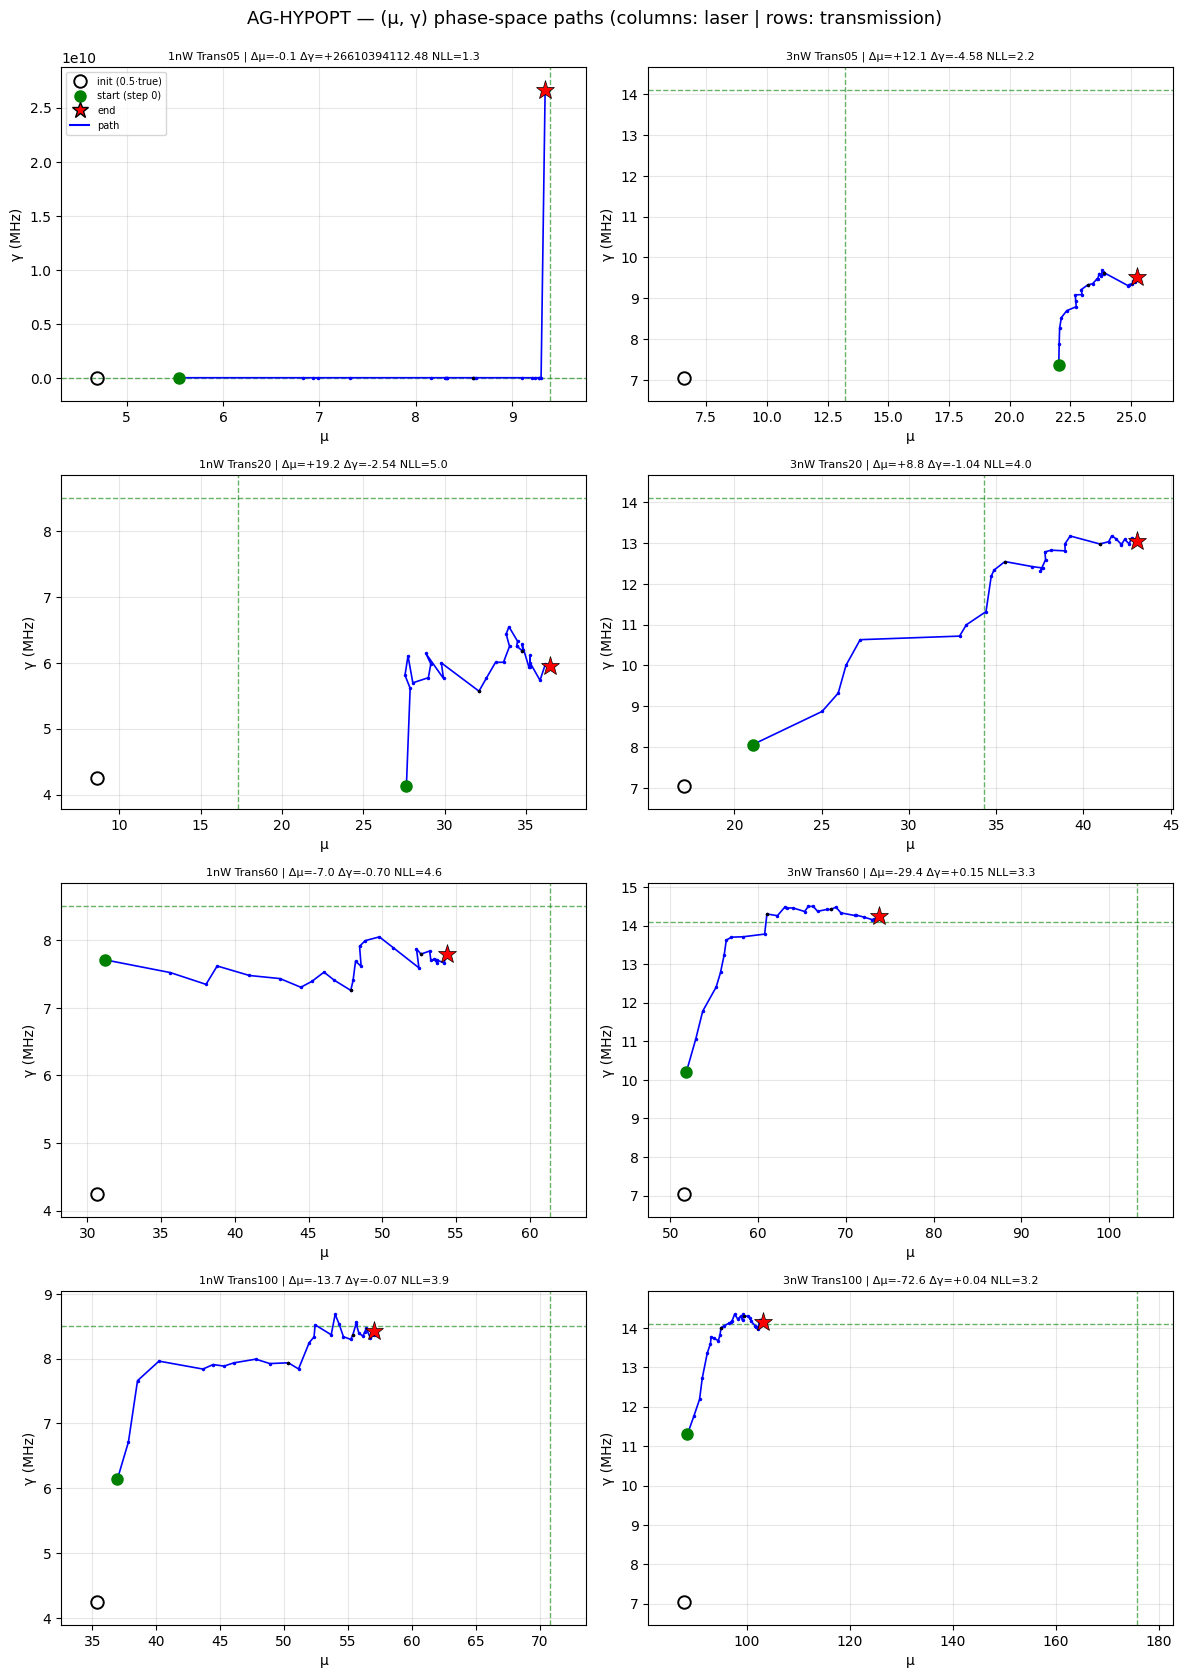

trial finished in 7.4 min
objective = 0.1362 ± 0.0919
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    9.34    -0.5 |     8.5026610394120.98+313063460146.8
1nW Trans20       17.32   36.48  +110.7 |     8.50    5.96   -29.9
1nW Trans60       61.37   54.38   -11.4 |     8.50    7.80    -8.3
1nW Trans100       70.82   57.08   -19.4 |     8.50    8.43    -0.8
3nW Trans05       13.20   25.25   +91.3 |    14.10    9.52   -32.5
3nW Trans20       34.28   43.07   +25.6 |    14.10   13.06    -7.4
3nW Trans60      103.20   73.82   -28.5 |    14.10   14.25    +1.1
3nW Trans100      175.71  103.07   -41.3 |    14.10   14.14    +0.3

weighted objective (T-graded, cap=1.0) = 0.1362 | diverged cells: 1
μ: RMSE 29.510 (rel 55.1%, bias -10.350) | γ: RMSE 9408195063.491 (rel 110684647805.8%, bias +3326299262.966)


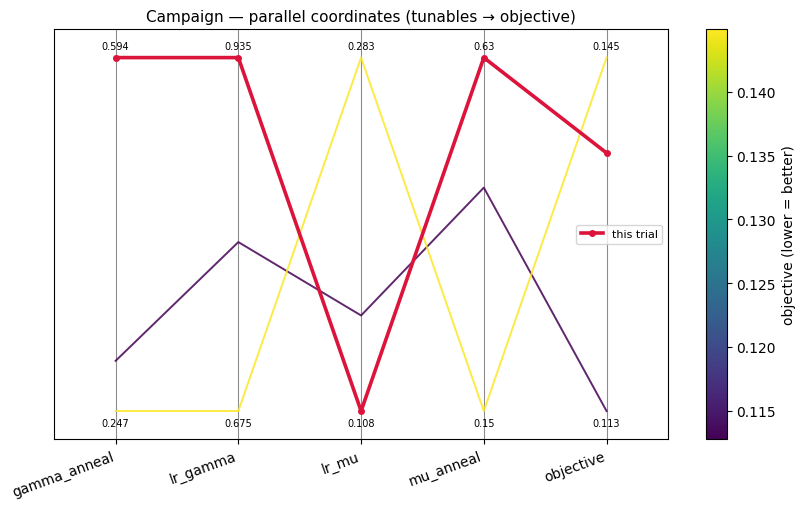

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 03 ran candidate 9: `lr_mu=0.1076`, `mu_anneal=0.6301`, `lr_gamma=0.9349`, `gamma_anneal=0.5944` (effective mu travel ~0.074, about 0.6x trial_01's 0.120). It completed in 7.4 min with objective **0.1362 +/- 0.0919** and **1 diverged cell** (1nW T05: gamma exploded to 2.66e10, far outside the [0.02, 500] guard). Ranking so far: trial_01 0.1127 < **trial_03 0.1362** < trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 55.1%** (RMSE 29.51, bias -10.35) — the best mu of the three trials (trial_01 77.1%, trial_02 136.4%); **gamma rel-RMSE** is dominated by the single diverged cell (raw RMSE 9.4e9). Excluding the diverged 1nW T05 cell, gamma is again accurate at high T (1nW T100 -0.8%, 3nW T100 +0.3%, 3nW T60 +1.1%) and degrades at low T (3nW T05 -32.5%, 1nW T20 -29.9%).

Per-cell relative errors (1nW T05 gamma is the diverged value; mu there was fine at -0.5%):
- **mu:** 1nW T05 -0.5% (diverged on gamma), T20 +110.7%, T60 -11.4%, T100 -19.4% | 3nW T05 +91.3%, T20 +25.6%, T60 -28.5%, T100 -41.3%.
- **gamma:** 1nW T05 diverged, T20 -29.9%, T60 -8.3%, T100 -0.8% | 3nW T05 -32.5%, T20 -7.4%, T60 +1.1%, T100 +0.3%.

Effect of the intended change (less mu travel, gamma step slightly higher): the mid/low-T mu overshoot shrank as expected (1nW T20 +157% -> +111% vs trial_01; 3nW T05 +137% -> +91%), and overall mu improved (rel-RMSE 77.1% -> 55.1%). But the high-T mu undershoot widened in the same move (1nW T100 -4.7% -> -19.4%; 3nW T60 -23.0% -> -28.5%; 3nW T100 -38.1% -> -41.3%), and because those high-T cells carry the largest objective weight, the net objective did not improve over trial_01. A gamma divergence also reappeared at 1nW T05 (as in trial_02).

**Summary:** Trial 03 (lr_mu=0.1076, mu_anneal=0.6301, lr_gamma=0.9349, gamma_anneal=0.5944): objective 0.1362 +/- 0.0919, 1 diverged cell (1nW T05, gamma ~2.7e10); reduced mu travel gave the best mu so far (rel-RMSE 77% -> 55%, mid-T overshoot cut) but widened the high-T mu undershoot, leaving the objective above trial_01.
**Key insight:** Reduced mu travel trades the mid-transmission mu overshoot for a larger high-transmission mu undershoot — mu accuracy improves (best rel-RMSE so far, 55%) but the heavily-weighted high-T part worsens, so the net objective (0.1362) still sits above trial_01's 0.1127.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The 1nW T05 gamma cell has now diverged in 2 of 3 trials (trial_02 mildly to -2.20, trial_03 explosively to 2.7e10) and only stayed finite in trial_01. The regimes do not isolate a single knob: the two diverging runs bracket trial_01 on mu travel (much larger in trial_02, much smaller in trial_03) and differ in lr_gamma (0.675 and 0.935 vs trial_01's 0.799). 1nW T05 is the smallest-n_target experiment, consistent with the documented low-count gamma noise/freeze failure mode, and the gamma step there is not being damped by the global schedule in either direction. If a later trial cannot remove it, a per-experiment gamma LR (or clipping/guard tuned for that cell) is the structural candidate; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 03 (lr_mu=0.1076, mu_anneal=0.6301, lr_gamma=0.9349, gamma_anneal=0.5944): objective 0.1362 +/- 0.0919, 1 diverged cell (1nW T05, gamma ~2.7e10); reduced mu travel gave the best mu so far (rel-RMSE 77% -> 55%, mid-T overshoot cut) but widened the high-T mu undershoot, leaving the objective above trial_01"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Reduced mu travel trades the mid-transmission mu overshoot for a larger high-transmission mu undershoot: mu accuracy improves (best rel-RMSE so far, 55%) but the heavily-weighted high-T part worsens, so the net objective (0.1362) still sits above trial_01's 0.1127"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
